# ST3 — Energy Policy: EDA & Visualization
**Team 7 Lambda | Phase 2**

Loads processed ST3 Parquet files and produces 4 charts:
1. Stacked area energy mix — faceted by focal country
2. Carbon price presence vs renewables share scatter
3. Policy divergence heatmap — renewables share by country × year
4. Renewable energy growth as mineral demand proxy (solar + wind trajectory)

**Palette:** `#A78BFA` (ST3 purple)

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import sys
sys.path.append('../../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from config import ST3_PROC, CHARTS, FOCAL_COUNTRIES
from utils import load_parquet, set_style, annotate_events, KEY_EVENTS, TEAM_PALETTE, log

set_style()
ST3_COLOR = TEAM_PALETTE['energy']   # #A78BFA
log.info('ST3 analysis setup complete.')

15:33:52 [INFO] ST3 analysis setup complete.


In [2]:
# ── Load ST3 Processed Data ─────────────────────────────────────────────────

def safe_load(fname, label):
    """
    Load a Parquet from DATA_PROC; return empty DataFrame if file missing.

    Args:
        fname: filename string
        label: log label

    Returns:
        DataFrame or empty DataFrame.

    Usage:
        energy_df = safe_load('st3_energy.parquet', 'Energy')
    """
    path = ST3_PROC / fname
    if not path.exists():
        log.warning(f'{label} not found at {path}. Run 03_ST3 ingestion first.')
        return pd.DataFrame()
    return load_parquet(path, label)


energy_df = safe_load('st3_energy.parquet',       'ST3 Energy')
carbon_df = safe_load('st3_carbon_price.parquet', 'ST3 Carbon')

# Filter to focal countries
FOCAL_ISO3 = list(FOCAL_COUNTRIES.keys())

if not energy_df.empty:
    energy_fc = energy_df[energy_df['iso3'].isin(FOCAL_ISO3)].copy()
    log.info(f'Energy (focal countries): {energy_fc.shape}')
else:
    energy_fc = pd.DataFrame()

if not carbon_df.empty:
    carbon_fc = carbon_df[carbon_df['iso3'].isin(FOCAL_ISO3)].copy()
    log.info(f'Carbon (focal countries): {carbon_fc.shape}')
else:
    carbon_fc = pd.DataFrame()

15:33:52 [INFO] Loaded ST3 Energy: 2,793 rows × 10 cols
15:33:52 [INFO] Loaded ST3 Carbon: 2,327 rows × 5 cols
15:33:52 [INFO] Energy (focal countries): (156, 10)
15:33:52 [INFO] Carbon (focal countries): (143, 5)


15:33:52 [INFO] Chart 1 saved: st3_energy_mix_faceted.png


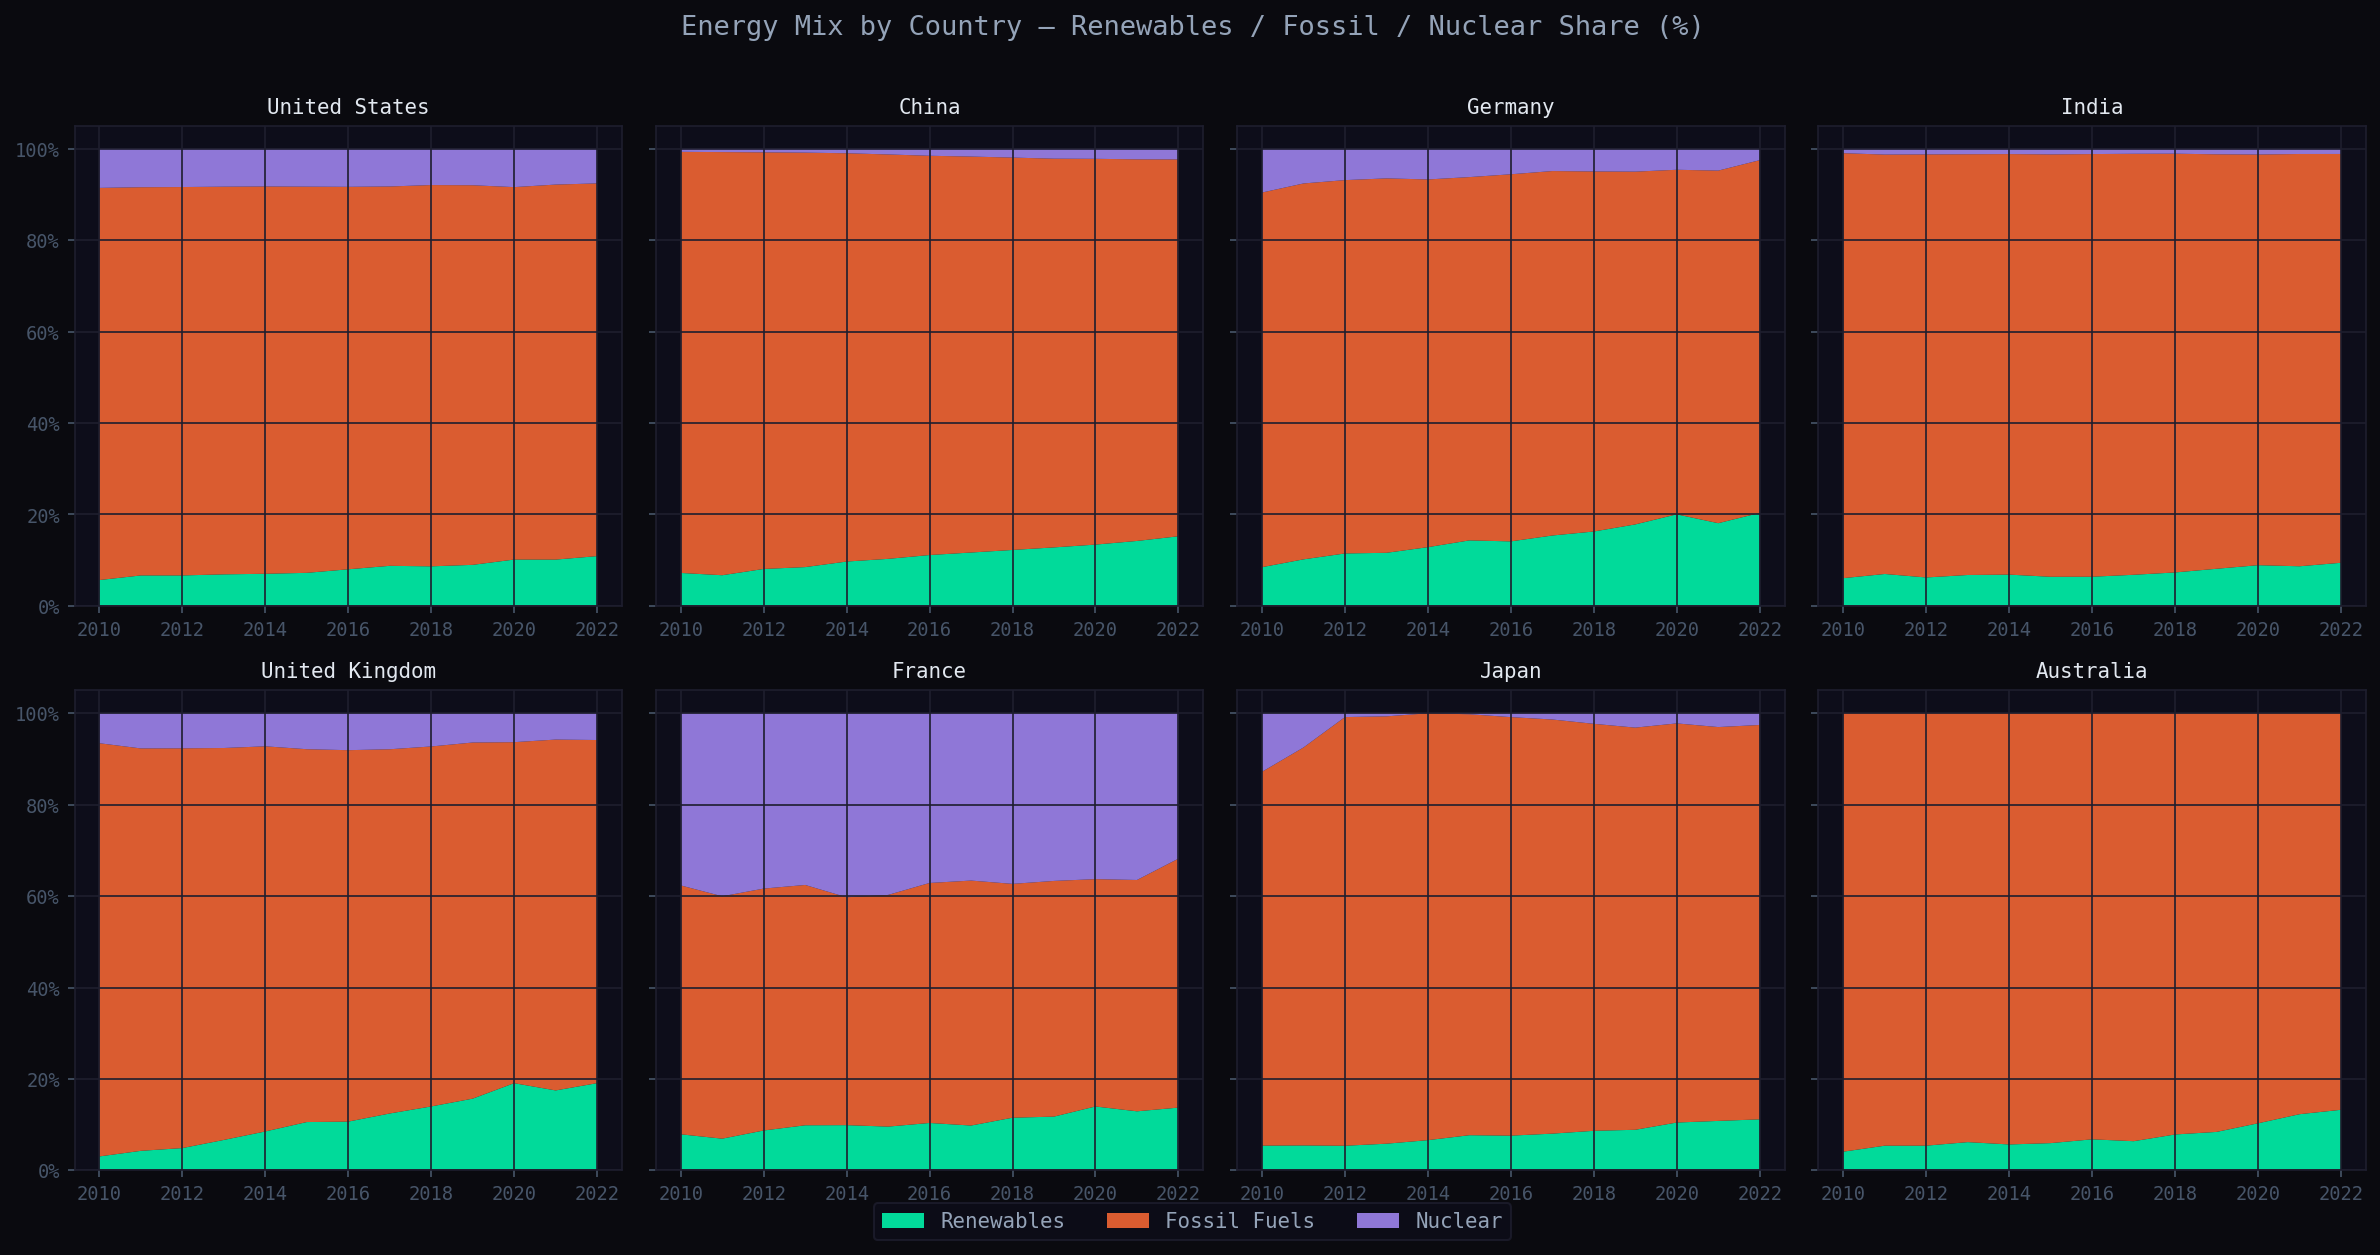

In [3]:
# ── Chart 1: Stacked Area Energy Mix — Faceted by Country ──────────────────
# Show renewables, fossil, nuclear share over time for key countries.
# Facet grid: 4 columns, as many rows as needed.

FOCUS_COUNTRIES = ['USA', 'CHN', 'DEU', 'IND', 'GBR', 'FRA', 'JPN', 'AUS']
MIX_COLS = ['renewables_share', 'fossil_share', 'nuclear_share']
MIX_COLORS = ['#00FFB2', '#FF6B35', '#A78BFA']
MIX_LABELS = ['Renewables', 'Fossil Fuels', 'Nuclear']

if not energy_fc.empty and all(c in energy_fc.columns for c in MIX_COLS):
    countries_avail = [c for c in FOCUS_COUNTRIES if c in energy_fc['iso3'].values]
    n_cols = 4
    n_rows = (len(countries_avail) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=True)
    axes = axes.flatten()

    for i, iso3 in enumerate(countries_avail):
        country_name = FOCAL_COUNTRIES.get(iso3, iso3)
        grp = energy_fc[energy_fc['iso3'] == iso3].sort_values('year')
        avail_mix = [c for c in MIX_COLS if c in grp.columns]

        if grp.empty or not avail_mix:
            axes[i].set_visible(False)
            continue

        # Convert integer year to datetime so axis units are compatible with
        # annotate_events which draws axvline(pd.Timestamp(...))
        year_dt = pd.to_datetime(grp['year'].astype(int), format='%Y')

        axes[i].stackplot(
            year_dt,
            [grp[c].fillna(0) for c in avail_mix],
            labels=MIX_LABELS[:len(avail_mix)],
            colors=MIX_COLORS[:len(avail_mix)],
            alpha=0.85,
        )
        axes[i].set_title(country_name, fontsize=10)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

    # Hide unused subplots
    for j in range(len(countries_avail), len(axes)):
        axes[j].set_visible(False)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle('Energy Mix by Country — Renewables / Fossil / Nuclear Share (%)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(CHARTS / 'st3_energy_mix_faceted.png')
    (CHARTS / 'st3_energy_mix_faceted.txt').write_text(
        'Stacked area charts show the evolution of energy mix (renewables, fossil fuels, nuclear) '
        'for 8 focal countries 2010-2022. Diverging trajectories — Germany and UK accelerating renewables, '
        'India still fossil-dominated — create asymmetric mineral demand profiles that differentially strain '
        'lithium, cobalt, and rare earth supply chains.'
    )
    log.info('Chart 1 saved: st3_energy_mix_faceted.png')
    plt.show()
else:
    log.warning('energy_fc empty or missing mix columns — skipping Chart 1.')

15:33:53 [INFO] Chart 2 saved: st3_carbon_vs_renewables.png


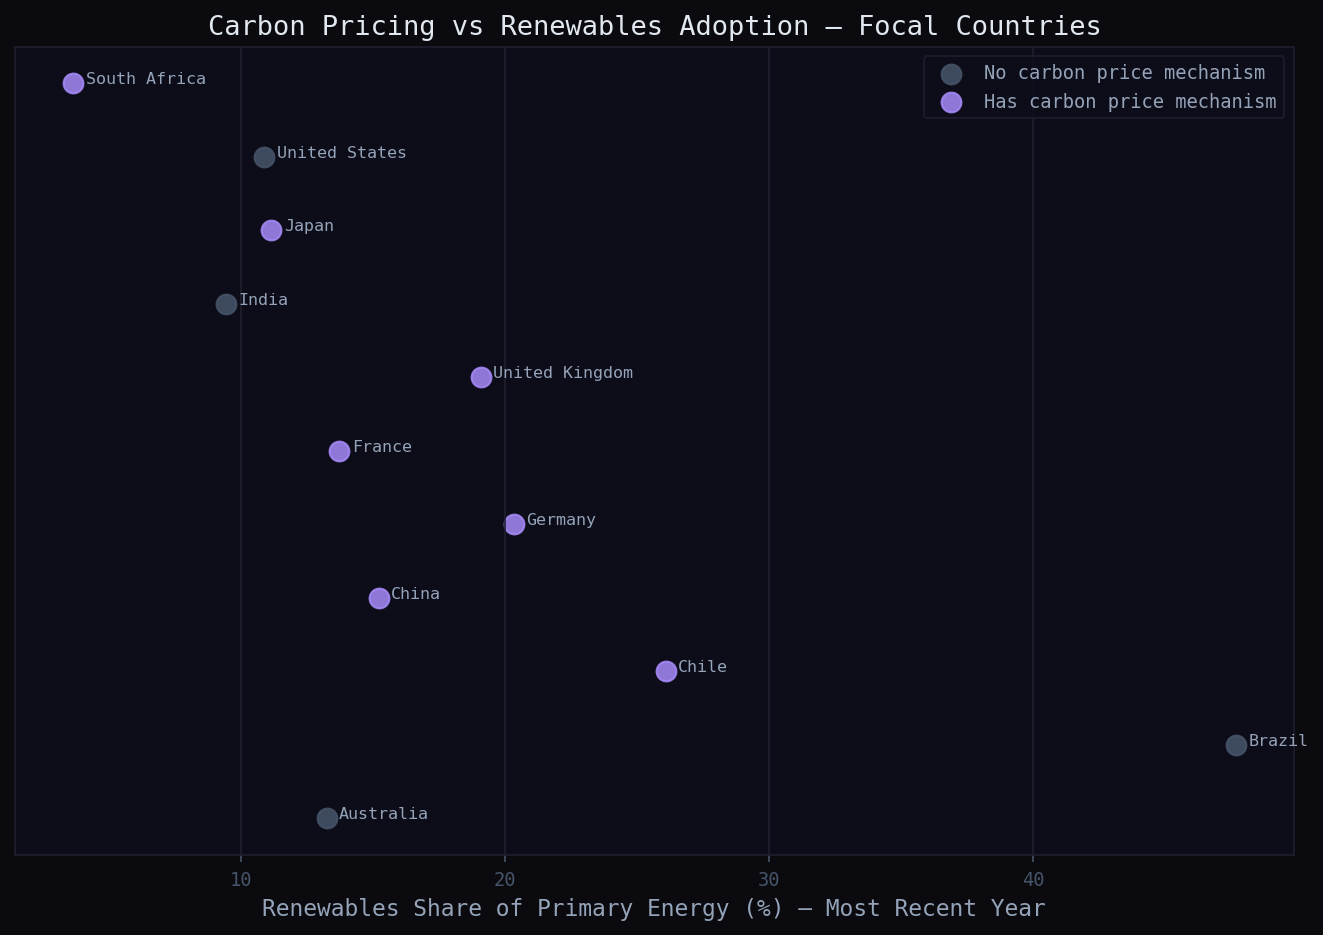

In [4]:
# ── Chart 2: Carbon Price Presence vs Renewables Share Scatter ──────────────
if not energy_fc.empty and not carbon_fc.empty and 'renewables_share' in energy_fc.columns:
    latest_energy = (
        energy_fc.sort_values('year')
        .groupby('iso3')
        .last()
        .reset_index()[['iso3', 'year', 'renewables_share']]
    )
    latest_carbon = (
        carbon_fc.sort_values('year')
        .groupby('iso3')
        .last()
        .reset_index()[['iso3', 'has_carbon_price', 'tax_price_local']]
    )

    scatter_df = latest_energy.merge(latest_carbon, on='iso3', how='left')
    scatter_df['has_carbon_price'] = scatter_df['has_carbon_price'].fillna(False)

    fig, ax = plt.subplots(figsize=(11, 7))

    for has_price, group in scatter_df.groupby('has_carbon_price'):
        color = ST3_COLOR if has_price else '#475569'
        label = 'Has carbon price mechanism' if has_price else 'No carbon price mechanism'
        ax.scatter(
            group['renewables_share'], group.index,
            color=color, s=90, alpha=0.85, label=label
        )
        for _, row in group.iterrows():
            name = FOCAL_COUNTRIES.get(row['iso3'], row['iso3'])
            ax.annotate(
                name, (row['renewables_share'], row.name),
                textcoords='offset points', xytext=(6, 0),
                fontsize=8, color='#94A3B8'
            )

    ax.set_xlabel('Renewables Share of Primary Energy (%) — Most Recent Year')
    ax.set_title('Carbon Pricing vs Renewables Adoption — Focal Countries')
    ax.set_yticks([])
    ax.legend(fontsize=9)
    plt.savefig(CHARTS / 'st3_carbon_vs_renewables.png')
    (CHARTS / 'st3_carbon_vs_renewables.txt').write_text(
        'Dot plot comparing renewables share (most recent year) with presence of a carbon pricing mechanism. '
        'Countries with active carbon pricing (green) tend to cluster at higher renewables shares, '
        'suggesting that policy instruments accelerate the energy transition and therefore amplify '
        'demand for transition minerals like lithium and cobalt.'
    )
    log.info('Chart 2 saved: st3_carbon_vs_renewables.png')
    plt.show()
else:
    log.warning('energy_fc or carbon_fc empty — skipping Chart 2.')

15:33:53 [INFO] Chart 3 saved: st3_policy_divergence_heatmap.png


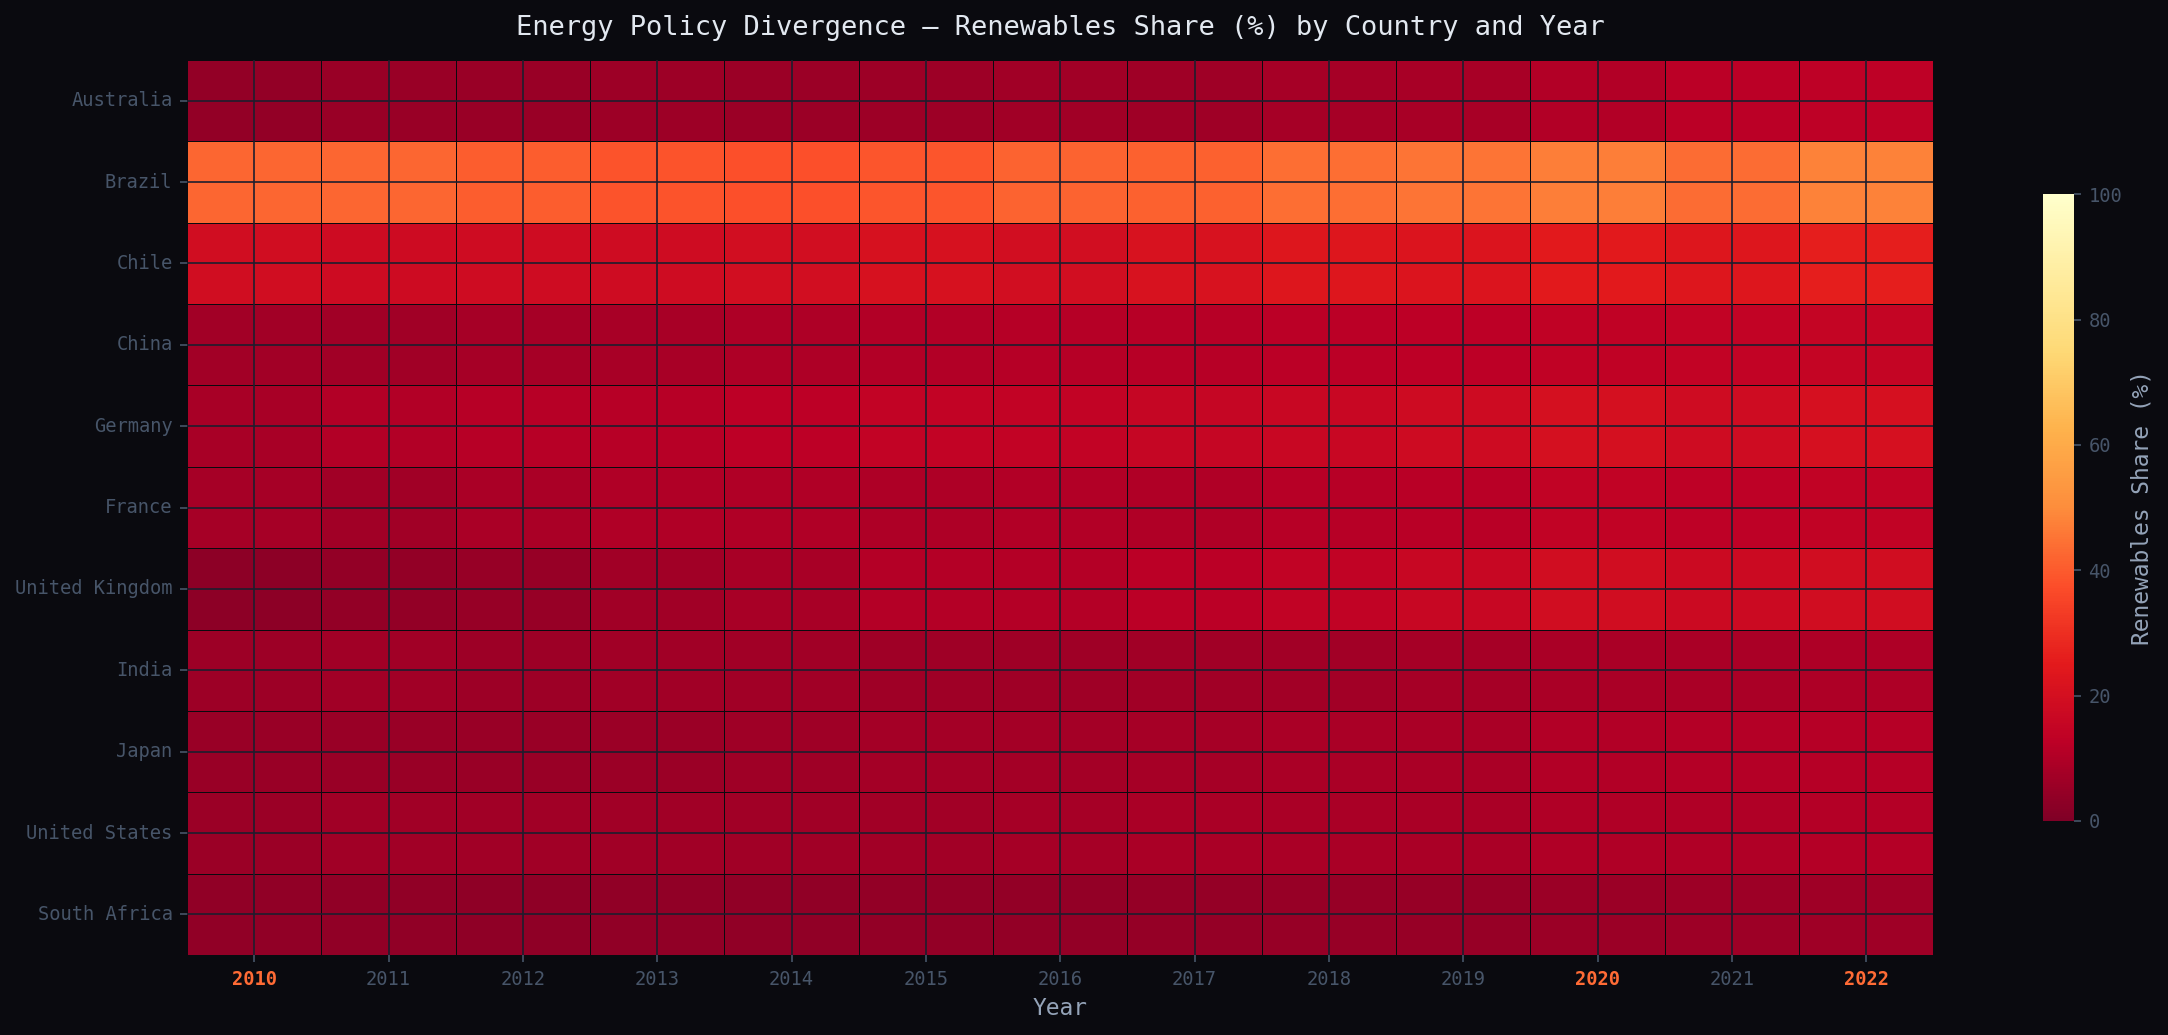

In [5]:
# ── Chart 3: Policy Divergence Heatmap — Renewables Share by Country × Year ─
if not energy_fc.empty and 'renewables_share' in energy_fc.columns:
    pivot = energy_fc.pivot_table(
        index='iso3', columns='year', values='renewables_share'
    )
    # Replace ISO-3 with country names
    pivot.index = [FOCAL_COUNTRIES.get(c, c) for c in pivot.index]

    fig, ax = plt.subplots(figsize=(16, 7))
    sns.heatmap(
        pivot,
        ax=ax,
        cmap='YlOrRd_r',
        linewidths=0.3,
        linecolor='#0A0A0F',
        annot=False,
        cbar_kws={'label': 'Renewables Share (%)', 'shrink': 0.7},
        vmin=0, vmax=100,
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('')
    ax.set_title('Energy Policy Divergence — Renewables Share (%) by Country and Year', pad=12)

    # Annotate major geopolitical events on x-axis
    year_labels = [int(t.get_text()) if t.get_text().isdigit() else None
                   for t in ax.get_xticklabels()]
    event_years = {pd.Timestamp(d).year: lbl for d, lbl in KEY_EVENTS}
    for tick, yr in zip(ax.get_xticklabels(), year_labels):
        if yr and yr in event_years:
            tick.set_color('#FF6B35')
            tick.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(CHARTS / 'st3_policy_divergence_heatmap.png')
    (CHARTS / 'st3_policy_divergence_heatmap.txt').write_text(
        'Heatmap of renewables share (%) for focal countries 2005-2024. '
        'Lighter (lower renewables) vs darker (higher renewables) rows reveal the asymmetric energy policy trajectories '
        'that create structurally different mineral demand growth rates across economies, '
        'driving differential pressure on critical mineral supply chains.'
    )
    log.info('Chart 3 saved: st3_policy_divergence_heatmap.png')
    plt.show()
else:
    log.warning('energy_fc empty or missing renewables_share — skipping Chart 3.')

15:33:53 [INFO] Chart 4 saved: st3_mineral_demand_projection.png


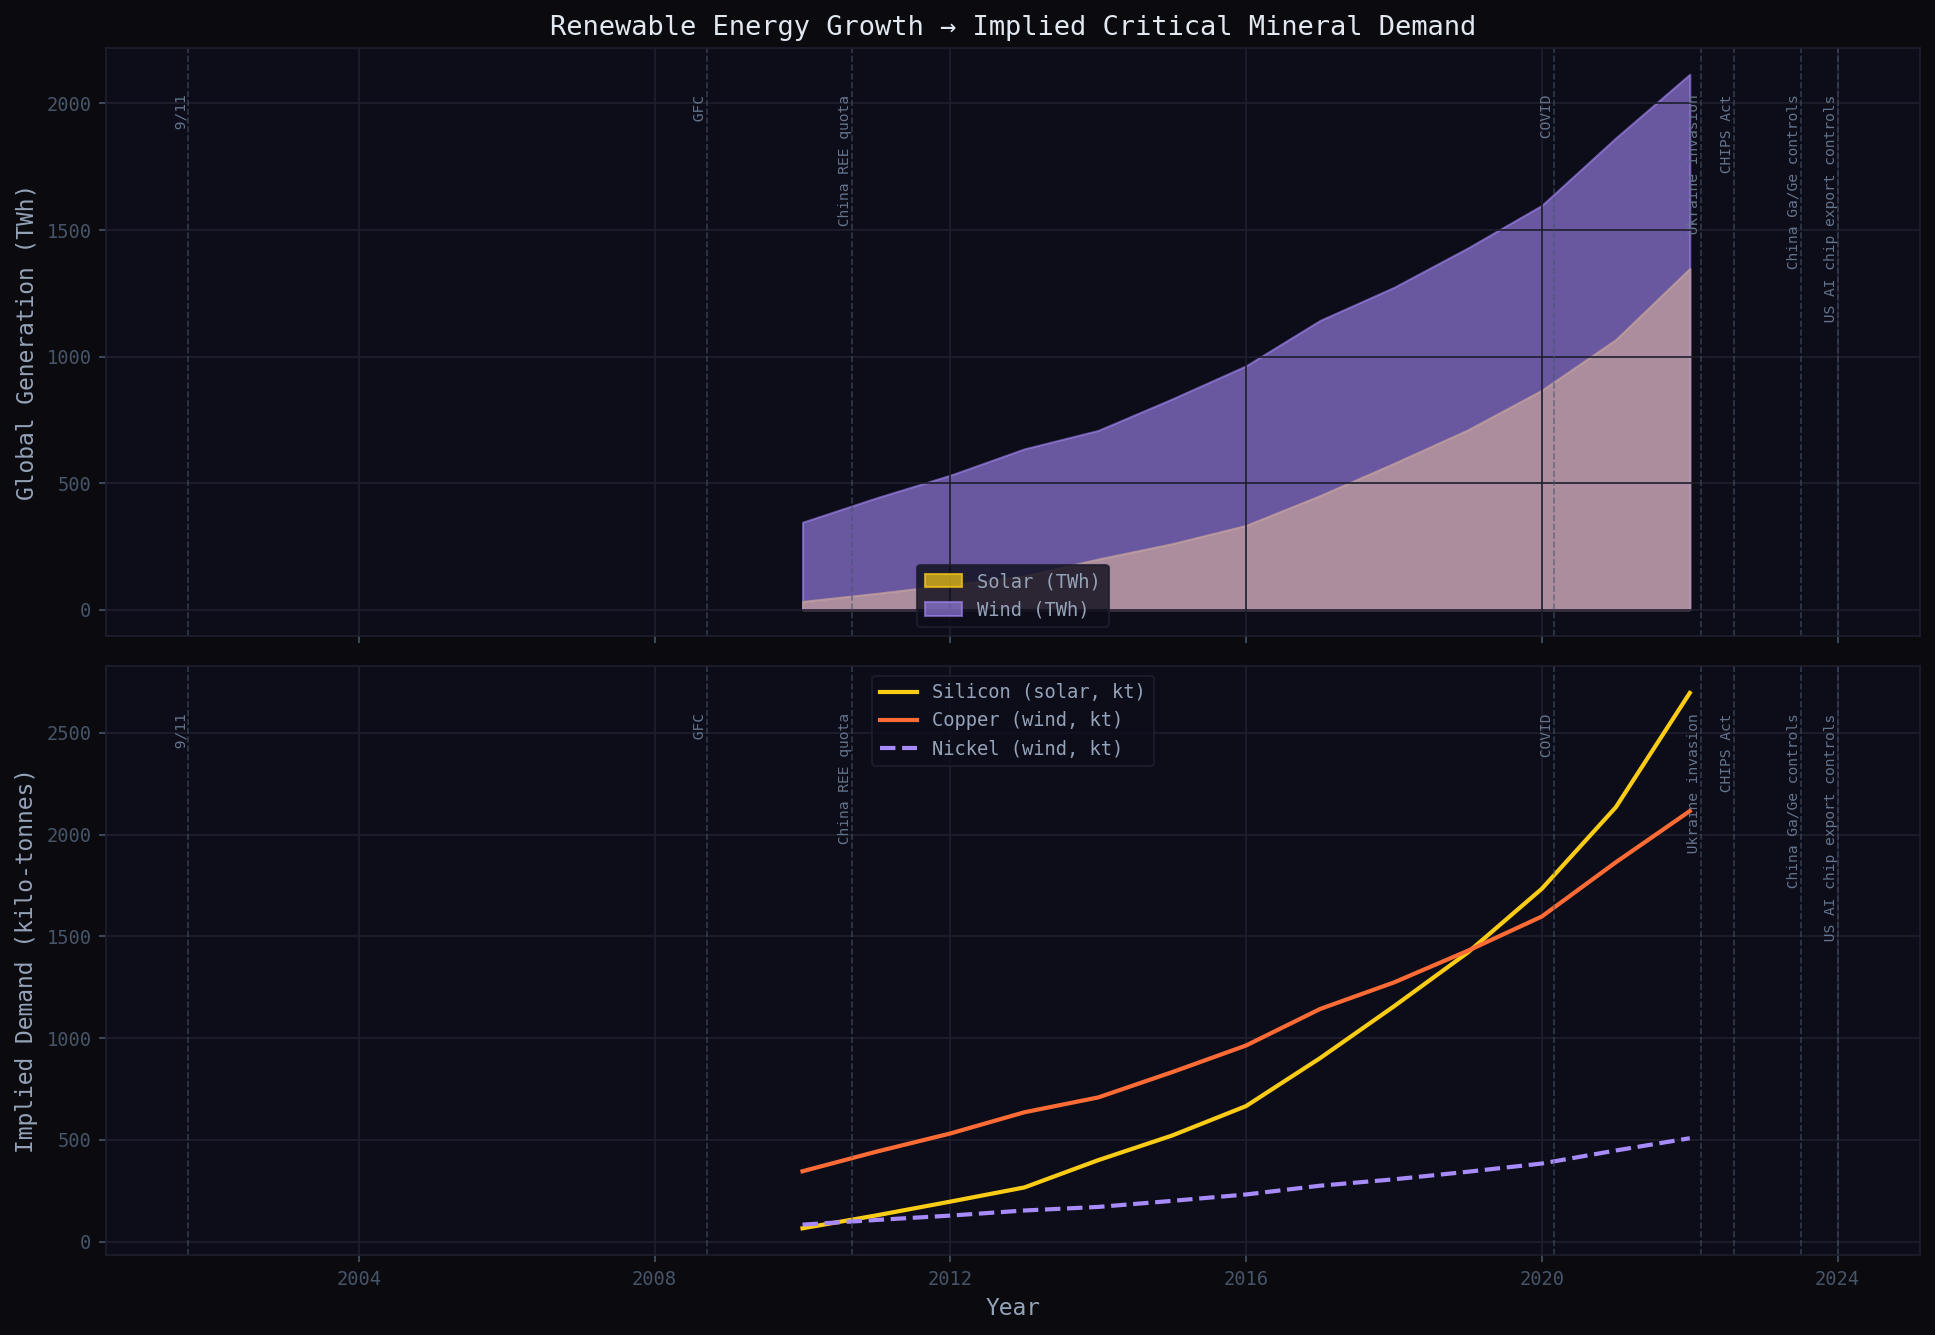

In [6]:
# ── Chart 4: Solar & Wind Growth as Mineral Demand Proxy ───────────────────
# Solar (TWh growth) → Silicon demand;  Wind (TWh growth) → Copper + Nickel demand.
# Published intensity factors from IEA 2023:
#   Solar: ~3 tonnes Si / MW  (~3,300 MWh/MW capacity → scaled from TWh)
#   Wind:  ~2.5 tonnes Cu + 0.6 tonnes Ni per MW
# Rough GWh-to-MW conversion assuming ~1,500 full-load hours/year for solar,
#   ~2,500 for wind (global average).

SI_PER_TWH_SOLAR   = 3.0    / 1.5     # tonnes Si per GWh → per TWh * 1000
CU_PER_TWH_WIND    = 2.5    / 2.5
NI_PER_TWH_WIND    = 0.6    / 2.5

if not energy_df.empty and 'solar_twh' in energy_df.columns and 'wind_twh' in energy_df.columns:
    # Global totals per year
    global_totals = (
        energy_df.groupby('year')[['solar_twh', 'wind_twh']]
        .sum()
        .reset_index()
        .sort_values('year')
    )

    # Implied mineral demand (kilo-tonnes for readability)
    global_totals['silicon_kt']  = global_totals['solar_twh'] * SI_PER_TWH_SOLAR
    global_totals['copper_kt']   = global_totals['wind_twh']  * CU_PER_TWH_WIND
    global_totals['nickel_kt']   = global_totals['wind_twh']  * NI_PER_TWH_WIND

    # Convert integer year to datetime so axis units are compatible with
    # annotate_events which draws axvline(pd.Timestamp(...))
    year_dt = pd.to_datetime(global_totals['year'].astype(int), format='%Y')

    fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

    # Top: solar + wind TWh
    axes[0].fill_between(year_dt, global_totals['solar_twh'],
                          alpha=0.7, color='#FACC15', label='Solar (TWh)')
    axes[0].fill_between(year_dt, global_totals['wind_twh'],
                          alpha=0.6, color=ST3_COLOR, label='Wind (TWh)')
    axes[0].set_ylabel('Global Generation (TWh)')
    axes[0].set_title('Renewable Energy Growth → Implied Critical Mineral Demand')
    axes[0].legend(fontsize=9)
    annotate_events(axes[0], KEY_EVENTS)

    # Bottom: implied mineral demand
    axes[1].plot(year_dt, global_totals['silicon_kt'],
                  color='#FACC15', linewidth=2, label='Silicon (solar, kt)')
    axes[1].plot(year_dt, global_totals['copper_kt'],
                  color='#FF6B35', linewidth=2, label='Copper (wind, kt)')
    axes[1].plot(year_dt, global_totals['nickel_kt'],
                  color=ST3_COLOR, linewidth=2, linestyle='--', label='Nickel (wind, kt)')
    axes[1].set_ylabel('Implied Demand (kilo-tonnes)')
    axes[1].set_xlabel('Year')
    axes[1].legend(fontsize=9)
    annotate_events(axes[1], KEY_EVENTS)

    plt.tight_layout()
    plt.savefig(CHARTS / 'st3_mineral_demand_projection.png')
    (CHARTS / 'st3_mineral_demand_projection.txt').write_text(
        'Top panel: global solar and wind electricity generation (TWh) 2010-2022. '
        'Bottom panel: implied critical mineral demand derived using IEA 2023 intensity factors '
        '(Si: 3t/MW solar; Cu: 2.5t/MW wind; Ni: 0.6t/MW wind). '
        'Exponential demand growth — entirely driven by energy policy choices (ST3) — directly '
        'stresses concentrated supply chains (ST1) and forces corporate CapEx reallocation (ST4).'
    )
    log.info('Chart 4 saved: st3_mineral_demand_projection.png')
    plt.show()
else:
    log.warning('energy_df empty or missing solar_twh/wind_twh — skipping Chart 4.')